# Shifted NFW: FMM-1 and MG vs direct reference

This notebook compares the shifted halo RAMSES outputs against the direct particle-sum slice generated from `nfw_shifted/ic_part`.


In [25]:
# -*- coding: utf-8 -*-
import os
import sys
from pathlib import Path
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import ScalarFormatter

sys.path.append("../utils/py")
import miniramses as ram

warnings.filterwarnings("ignore")
plt.rcParams["font.family"] = "serif"
plt.rcParams["figure.dpi"] = 150
plt.rcParams.update({
    "font.size": 20,
    "legend.fontsize": 18,
})

ROOT = Path("/home/jl4415/mini-ramses")
FMM_OUTPUT = ROOT / "shift_halo" / "fmm" / "output_00002"
MG_OUTPUT = ROOT / "shift_halo" / "mg" / "output_00002"
DIRECT_REFERENCE = Path("./txt/direct_phi_shifted_slice_lvl9_zcell128.txt")
FIG_DIR = Path("./fig")
FIG_DIR.mkdir(exist_ok=True)

BOX_CUT = 300.0
BOX_LENGTH = 2.0 * BOX_CUT
LEVELMIN = 9
Z_CELL = 128
SLICE_CENTER = 600.0
NPIX = 2 ** (LEVELMIN - 1)

FIELD_INDEX = {
    "phi": 0,
    "fx": 1,
    "fy": 2,
    "fz": 3,
}

_COL_LABELS = {
    "phi": r"$\Phi$",
    "fx":  r"$f_x$",
    "fy":  r"$f_y$",
    "fz":  r"$f_z$",
    "f":   r"$|\mathbf{f}|$",
}

_COL_ERR_LABELS = {
    "phi": r"$(\Phi_\mathrm{sim}-\Phi_\mathrm{true})/\Phi_\mathrm{true}$",
    "fx":  r"$(f_{x,\mathrm{sim}}-f_{x,\mathrm{true}})/f_{x,\mathrm{true}}$",
    "fy":  r"$(f_{y,\mathrm{sim}}-f_{y,\mathrm{true}})/f_{y,\mathrm{true}}$",
    "fz":  r"$(f_{z,\mathrm{sim}}-f_{z,\mathrm{true}})/f_{z,\mathrm{true}}$",
    "f":   r"$(|\mathbf{f}|_\mathrm{sim}-|\mathbf{f}|_\mathrm{direct})/|\mathbf{f}|_\mathrm{direct}$",
}


In [26]:
def normalize_dir(path):
    return os.path.abspath(path)


def infer_isort(prefix):
    if prefix is None:
        prefix = "hydro"

    prefix = prefix.lower()
    if prefix in ["hydro", "grav", "rt"]:
        return 0
    if prefix == "peak":
        return 1
    raise ValueError(f"Unknown prefix: {prefix}")


def read_output(output_path):
    """Read one RAMSES output directory, following the helper pattern in amr.ipynb."""
    output_path = normalize_dir(output_path)
    nout_dir = os.path.basename(output_path)
    base_path = os.path.dirname(output_path)

    if not nout_dir.startswith("output_"):
        raise ValueError(f"Expected path like '.../output_00002', got: {output_path}")

    nout = nout_dir.split("_")[-1]
    print("Reading nout:", nout, "from", base_path)

    last_err = None
    for prefix in ["grav", "hydro", "rt", "peak"]:
        try:
            infer_isort(prefix)
            c = ram.rd_cell(nout, path=base_path, prefix=prefix)
            info = ram.rd_info(nout, path=base_path)
            print(f"[OK] {output_path} (prefix='{prefix}')")
            return c, info, prefix
        except Exception as err:
            last_err = err

    raise RuntimeError(f"Failed to read {output_path}. Last error: {last_err}")


def amr_slice(c, cen=SLICE_CENTER, levels=None):
    """Select cells intersecting the plane z=cen."""
    mask = np.abs(c.x[2] - cen) <= c.dx / 2
    if levels is not None:
        mask &= np.isin(c.level, levels)
    return c.x[0][mask], c.x[1][mask], c.dx[mask], c.level[mask], mask


def render_amr_slice(c, plot_col="phi", cen=SLICE_CENTER, levels=None, npix=NPIX, box=None):
    """Rasterize an AMR slice to a fixed grid so it can be compared to direct.py output."""
    x, y, dx, level, mask = amr_slice(c, cen=cen, levels=levels)

    if plot_col == "f":
        fx = c.g[FIELD_INDEX["fx"]][mask]
        fy = c.g[FIELD_INDEX["fy"]][mask]
        fz = c.g[FIELD_INDEX["fz"]][mask]
        val = np.sqrt(fx**2 + fy**2 + fz**2)
    else:
        val = c.g[FIELD_INDEX[plot_col]][mask]

    if box is None:
        xmin = np.nanmin(x - dx / 2)
        xmax = np.nanmax(x + dx / 2)
        ymin = np.nanmin(y - dx / 2)
        ymax = np.nanmax(y + dx / 2)
    else:
        xmin, xmax, ymin, ymax = box

    sx = npix / (xmax - xmin)
    sy = npix / (ymax - ymin)
    img = np.full((npix, npix), np.nan)

    order = np.argsort(-dx)
    for i in order:
        x0 = x[i] - dx[i] / 2
        x1 = x[i] + dx[i] / 2
        y0 = y[i] - dx[i] / 2
        y1 = y[i] + dx[i] / 2

        if x1 <= xmin or x0 >= xmax or y1 <= ymin or y0 >= ymax:
            continue

        x0c = max(x0, xmin)
        x1c = min(x1, xmax)
        y0c = max(y0, ymin)
        y1c = min(y1, ymax)

        ix0 = max(int(np.floor((x0c - xmin) * sx)), 0)
        ix1 = min(int(np.ceil((x1c - xmin) * sx)), npix)
        iy0 = max(int(np.floor((y0c - ymin) * sy)), 0)
        iy1 = min(int(np.ceil((y1c - ymin) * sy)), npix)

        if ix1 > ix0 and iy1 > iy0:
            img[iy0:iy1, ix0:ix1] = val[i]

    print(f"{plot_col}: AMR image range", np.nanmin(img), np.nanmax(img))
    return img, [xmin, xmax, ymin, ymax]


def display_extent_from_box(box):
    xmin, xmax, ymin, ymax = map(float, box)
    return [0.0, xmax - xmin, 0.0, ymax - ymin]


def load_direct_slice(reference_file=DIRECT_REFERENCE, plot_col="phi"):
    """Load direct.py's shifted reference: columns x y z fx fy fz phi."""
    reference_file = Path(reference_file)
    if not reference_file.exists():
        raise FileNotFoundError(
            f"Missing direct reference: {reference_file}. "
            "Wait for the shifted direct SLURM job to finish, then rerun this cell."
        )

    names = ["x", "y", "z", "fx", "fy", "fz", "phi"]
    df = pd.read_csv(reference_file, sep=r"\s+", comment="#", names=names)
    df["f"] = np.sqrt(df["fx"]**2 + df["fy"]**2 + df["fz"]**2)

    x_unique = np.sort(df["x"].unique())
    y_unique = np.sort(df["y"].unique())
    grid = df.pivot(index="y", columns="x", values=plot_col).loc[y_unique, x_unique].values

    extent = [x_unique.min(), x_unique.max(), y_unique.min(), y_unique.max()]
    print(f"{plot_col}: direct grid shape", grid.shape, "range", np.nanmin(grid), np.nanmax(grid))
    return grid, extent


In [27]:
def plot_shifted_vs_direct(
    plot_col="phi",
    cen=SLICE_CENTER,
    levels=None,
    fmm_output=FMM_OUTPUT,
    mg_output=MG_OUTPUT,
    reference_file=DIRECT_REFERENCE,
    npix=NPIX,
    save=True,
    output_prefix="shifted_fmm1_mg_vs_direct",
):
    """Make a 2x2 comparison: FMM-1, MG, and their relative errors vs direct."""
    print("\n" + "=" * 60)
    print(f"Plotting shifted NFW: {plot_col} vs direct reference")
    print("=" * 60)

    direct_grid, direct_extent = load_direct_slice(reference_file, plot_col=plot_col)
    if direct_grid.shape != (npix, npix):
        npix = direct_grid.shape[0]
        print("Using npix from direct reference:", npix)

    c_fmm, _, _ = read_output(fmm_output)
    c_mg, _, _ = read_output(mg_output)

    fmm_grid, amr_extent = render_amr_slice(c_fmm, plot_col=plot_col, cen=cen, levels=levels, npix=npix)
    mg_grid, _ = render_amr_slice(c_mg, plot_col=plot_col, cen=cen, levels=levels, npix=npix, box=amr_extent)
    display_extent = display_extent_from_box(amr_extent)
    print("display extent:", display_extent)

    with np.errstate(divide="ignore", invalid="ignore"):
        fmm_rel = (fmm_grid - direct_grid) / direct_grid
        mg_rel = (mg_grid - direct_grid) / direct_grid

    sim_grids = [fmm_grid, mg_grid]
    err_grids = [fmm_rel, mg_rel]
    labels = ["FMM-1", "MG"]

    vmin = np.nanmin([np.nanmin(g) for g in sim_grids])
    vmax = np.nanmax([np.nanmax(g) for g in sim_grids])
    vmax_err = np.nanmax([np.nanmax(np.abs(e[np.isfinite(e)])) for e in err_grids])

    fig, axes = plt.subplots(2, 2, figsize=(11, 10), constrained_layout=True)

    ims = []
    for i, (grid, label) in enumerate(zip(sim_grids, labels)):
        ax = axes[0, i]
        im = ax.imshow(
            grid,
            origin="lower",
            cmap="viridis",
            vmin=vmin,
            vmax=vmax,
            extent=display_extent,
            interpolation="nearest",
        )
        ims.append(im)
        ax.set_title(label, fontsize=20)
        ax.set_xlabel("x")
        if i == 0:
            ax.set_ylabel("y")

    cbar = fig.colorbar(ims[-1], ax=axes[0, :], location="right", fraction=0.046, pad=0.04)
    formatter = ScalarFormatter(useMathText=True)
    formatter.set_powerlimits((0, 0))
    cbar.ax.yaxis.set_major_formatter(formatter)
    cbar.update_ticks()
    cbar.set_label(_COL_LABELS.get(plot_col, plot_col))

    err_ims = []
    for i, (err, label) in enumerate(zip(err_grids, labels)):
        ax = axes[1, i]
        im = ax.imshow(
            err,
            origin="lower",
            cmap="RdYlGn",
            vmin=-vmax_err,
            vmax=vmax_err,
            extent=display_extent,
            interpolation="nearest",
        )
        err_ims.append(im)

        finite_abs = np.abs(err[np.isfinite(err)])
        p90, p99 = np.nanpercentile(finite_abs, [90, 99])
        ax.set_title("Relative Error\n" + rf"$P_{{90}}$: {p90:.2e}, $P_{{99}}$: {p99:.2e}", fontsize=15)
        ax.set_xlabel("x")
        if i == 0:
            ax.set_ylabel("y")

        print(f"{label} {plot_col}: P90={p90:.4e}, P99={p99:.4e}")

    cbar_err = fig.colorbar(err_ims[-1], ax=axes[1, :], location="right", fraction=0.046, pad=0.04)
    cbar_err.set_label(_COL_ERR_LABELS.get(plot_col, f"relative error {plot_col}"))

    if save:
        out = FIG_DIR / f"{output_prefix}_{plot_col}.pdf"
        fig.savefig(out, dpi=250, bbox_inches="tight")
        print("Saved:", out)

    return fig, axes



Plotting shifted NFW: phi vs direct reference
phi: direct grid shape (256, 256) range -134284.55544 -9935.3982203
Reading nout: 00002 from /home/jl4415/mini-ramses/shift_halo/fmm
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo/fmm/output_00002 (prefix='grav')
Reading nout: 00002 from /home/jl4415/mini-ramses/shift_halo/mg
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo/mg/output_00002 (prefix='grav')
phi: AMR image range -129900.1328125 -9932.7958984375
phi: AMR image range -133802.796875 -9956.078125
display extent: [0.0, 600.0, 0.0, 600.0]
FMM-1 phi: P90=

(<Figure size 1650x1500 with 6 Axes>,
 array([[<AxesSubplot:title={'center':'FMM-1'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'MG'}, xlabel='x'>],
        [<AxesSubplot:title={'center':'Relative Error\n$P_{90}$: 7.59e-03, $P_{99}$: 1.45e-02'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'Relative Error\n$P_{90}$: 8.63e-03, $P_{99}$: 3.69e-02'}, xlabel='x'>]],
       dtype=object))

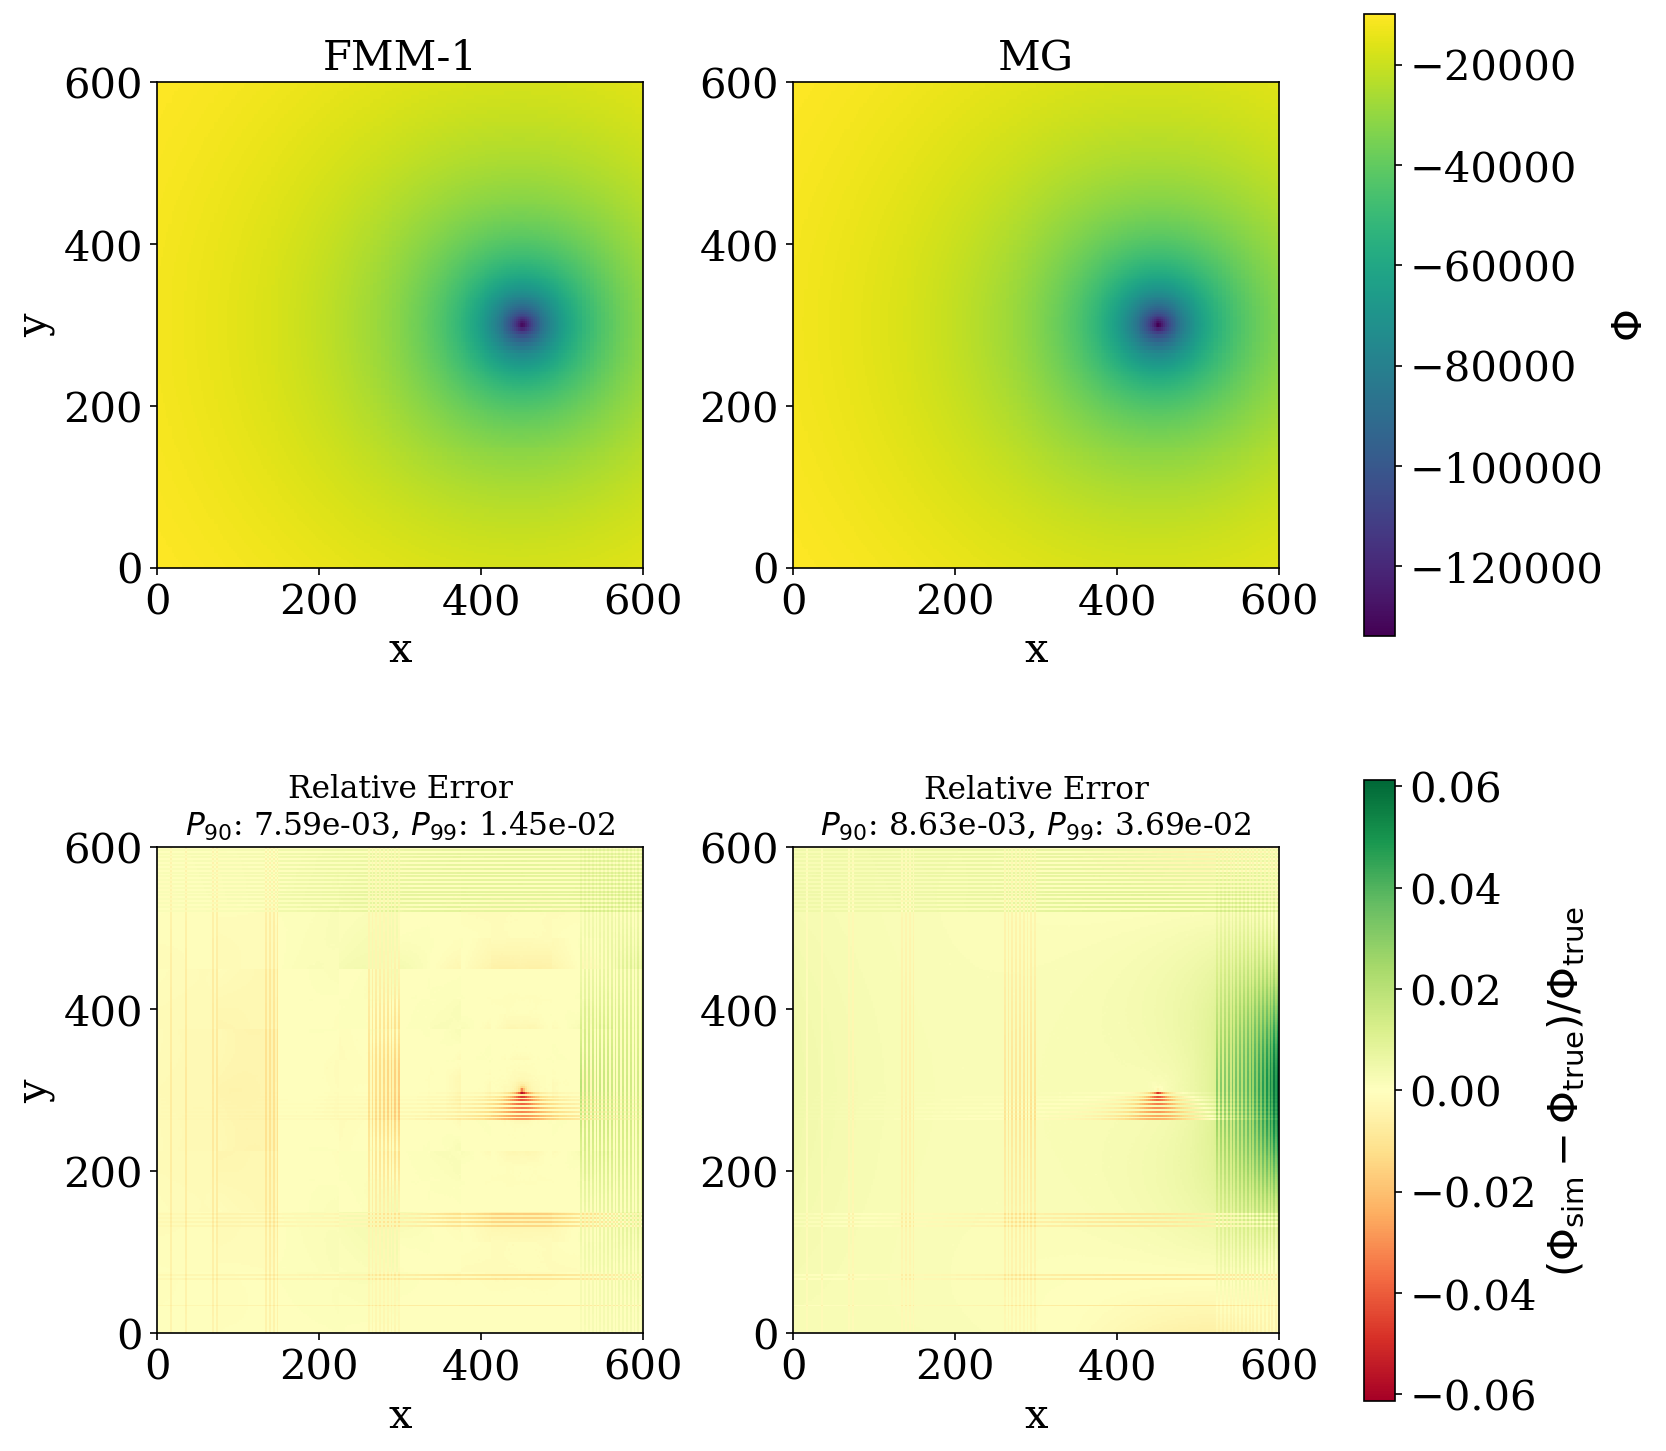

In [28]:
plot_shifted_vs_direct(plot_col="phi")


Plotting shifted NFW: f vs direct reference
f: direct grid shape (256, 256) range 18.60013371605722 3643.7970488328983
Reading nout: 00002 from /home/jl4415/mini-ramses/shift_halo/fmm
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo/fmm/output_00002 (prefix='grav')
Reading nout: 00002 from /home/jl4415/mini-ramses/shift_halo/mg
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo/mg/output_00002 (prefix='grav')
f: AMR image range 18.706603035425307 2405.8135239621975
f: AMR image range 18.709495965809904 2923.095189348856
display extent: [0.0, 600.0, 0.0, 600.0]


(<Figure size 1650x1500 with 6 Axes>,
 array([[<AxesSubplot:title={'center':'FMM-1'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'MG'}, xlabel='x'>],
        [<AxesSubplot:title={'center':'Relative Error\n$P_{90}$: 2.89e-02, $P_{99}$: 1.44e-01'}, xlabel='x', ylabel='y'>,
         <AxesSubplot:title={'center':'Relative Error\n$P_{90}$: 2.33e-02, $P_{99}$: 6.15e-02'}, xlabel='x'>]],
       dtype=object))

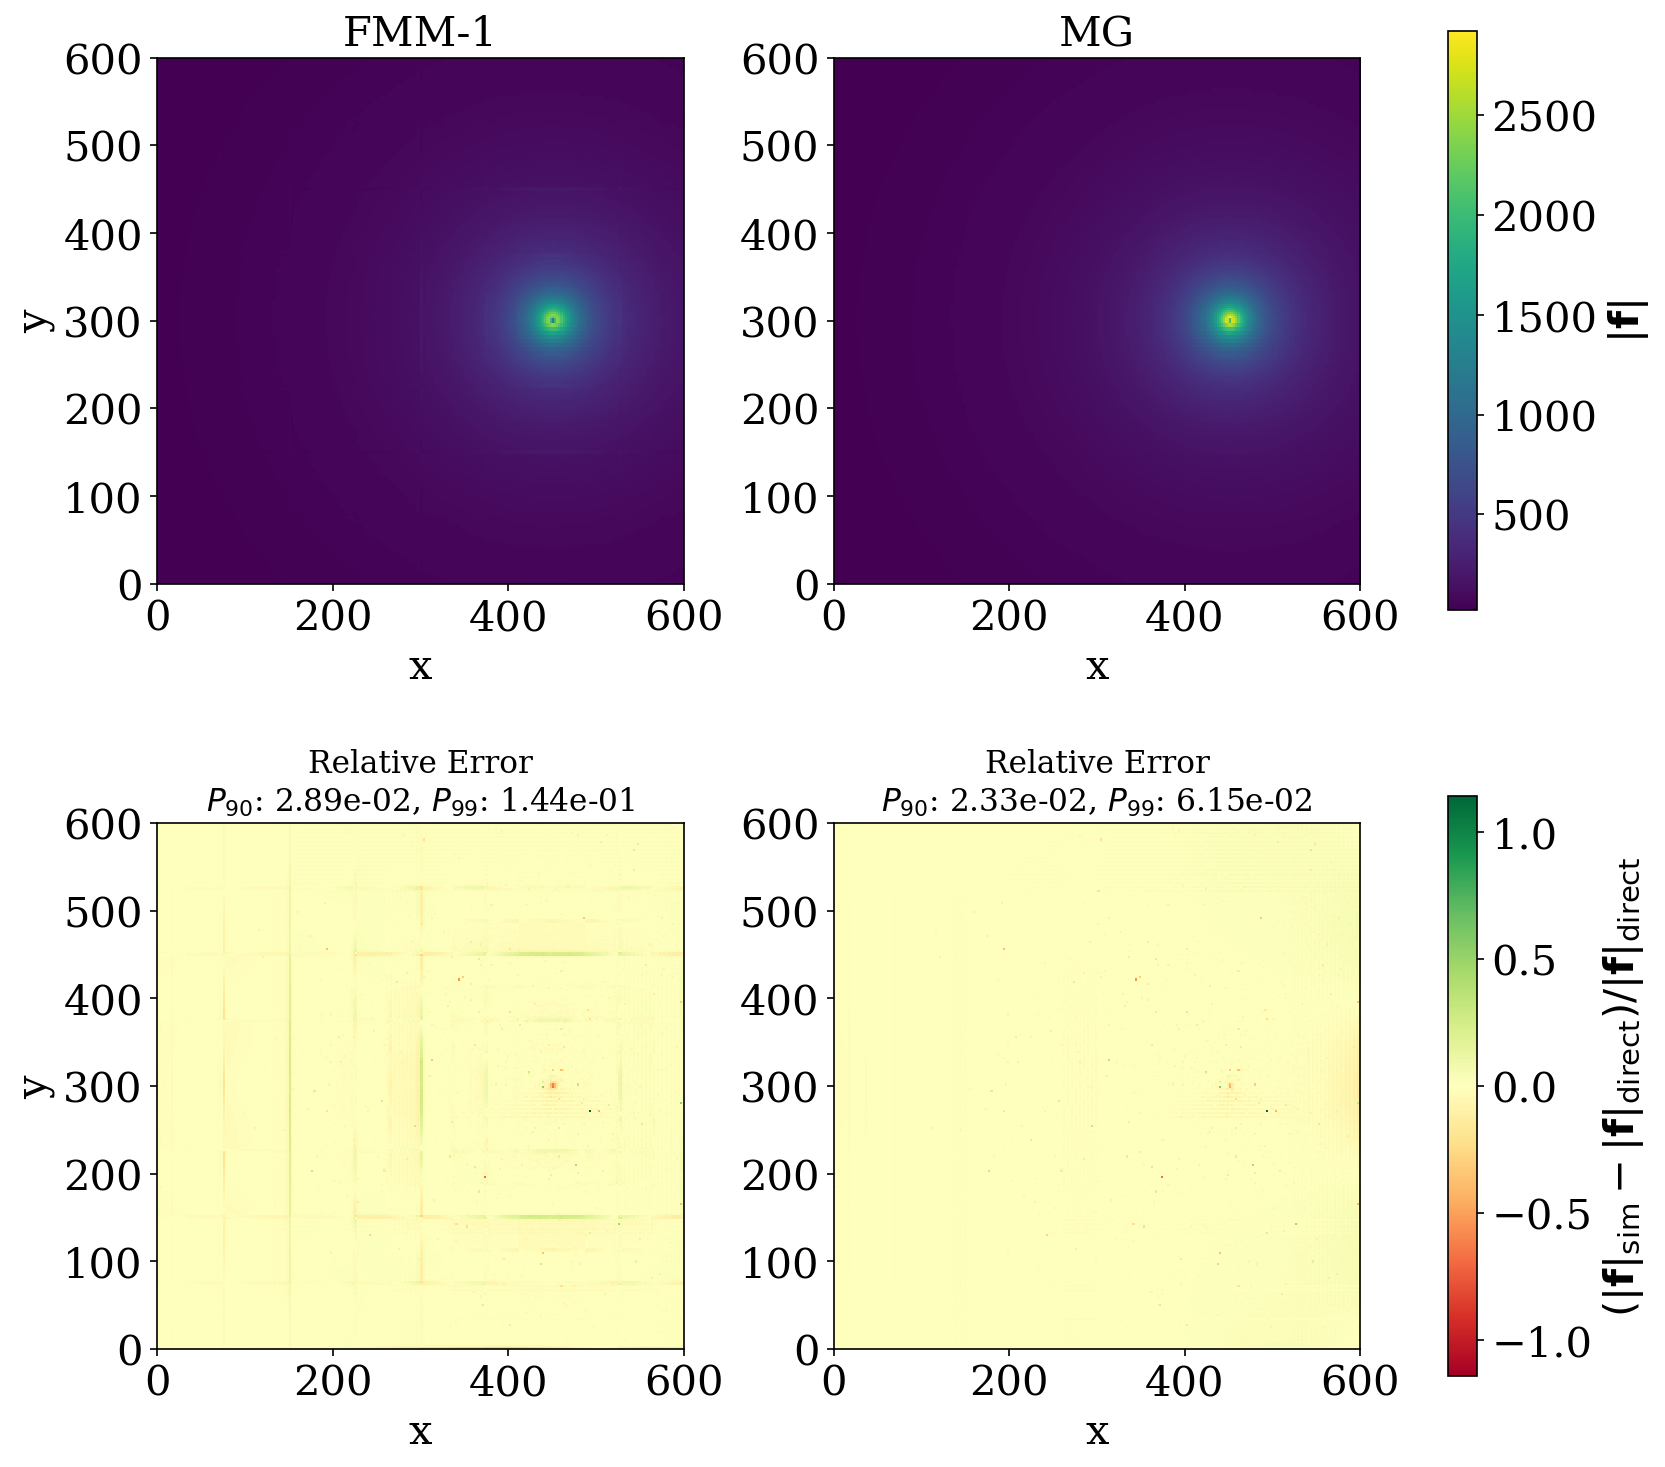

In [24]:
plot_shifted_vs_direct(plot_col="f")


Plotting shifted NFW: phi vs direct reference
phi: direct grid shape (256, 256) range -133105.89409 -9960.6178812
Reading nout: 00002 from /home/jl4415/mini-ramses/shift_halo2/fmm
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo2/fmm/output_00002 (prefix='grav')
Reading nout: 00002 from /home/jl4415/mini-ramses/shift_halo2/mg
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo2/mg/output_00002 (prefix='grav')
phi: AMR image range -129365.484375 -9957.810546875
phi: AMR image range -132729.0 -9981.1064453125
display extent: [0.0, 600.0, 0.0, 600.0]
FMM-1 phi: P90

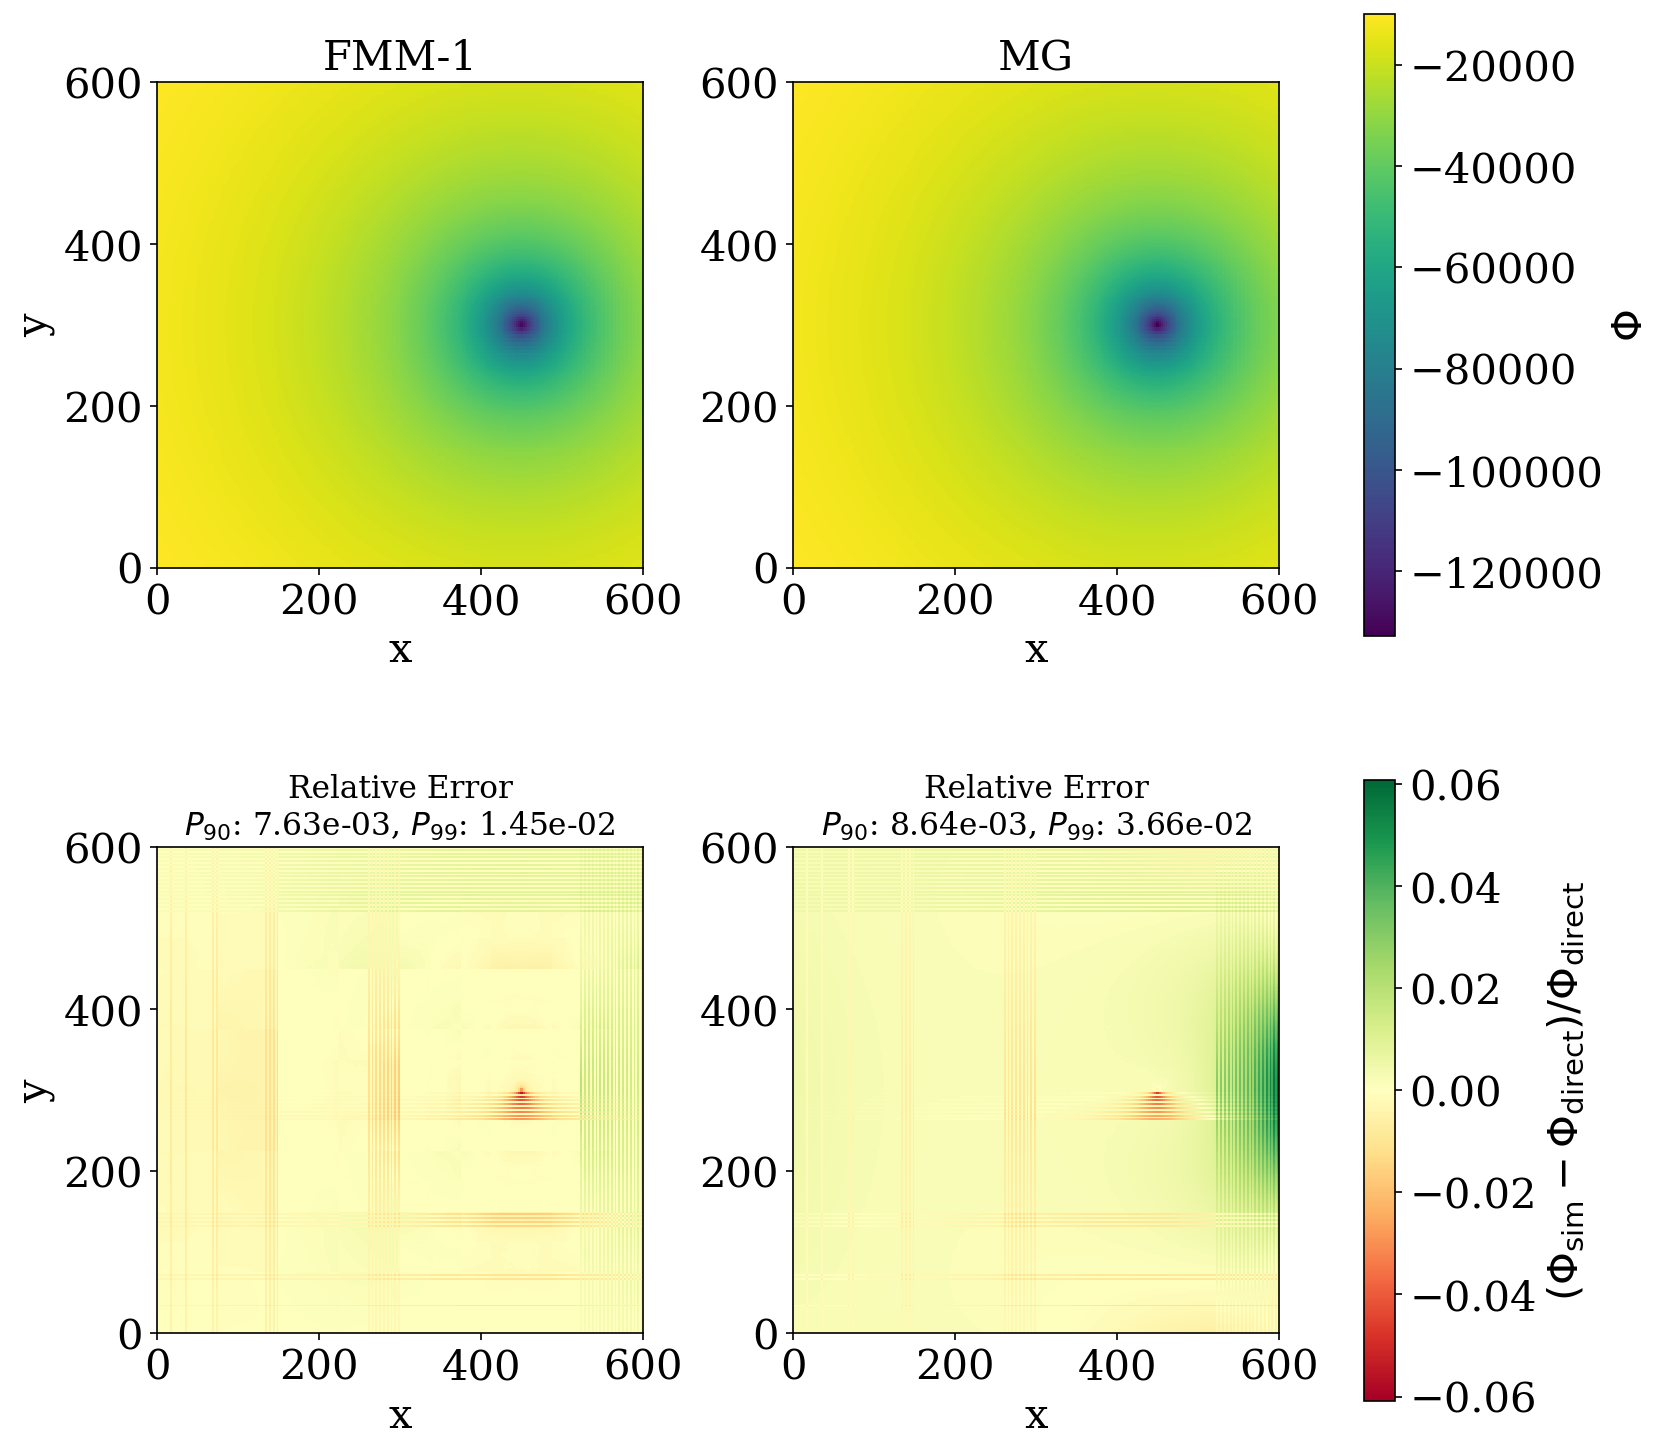

In [17]:
# Shifted2 comparison: NFW shifted by +300 in x.
SHIFTED2_FMM_OUTPUT = ROOT / "shift_halo2" / "fmm" / "output_00002"
SHIFTED2_MG_OUTPUT = ROOT / "shift_halo2" / "mg" / "output_00002"
SHIFTED2_DIRECT_REFERENCE = Path("./txt/direct_phi_shifted2_slice_lvl9_zcell128.txt")

for plot_col in ["phi"]:
    plot_shifted_vs_direct(
        plot_col=plot_col,
        fmm_output=SHIFTED2_FMM_OUTPUT,
        mg_output=SHIFTED2_MG_OUTPUT,
        reference_file=SHIFTED2_DIRECT_REFERENCE,
        output_prefix="shifted2_fmm1_mg_vs_direct",
    )



Plotting shifted NFW: phi vs direct reference
phi: direct grid shape (256, 256) range -135308.70791 -13074.612727
Reading nout: 00002 from /home/jl4415/mini-ramses/shift_halo3/fmm
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo3/fmm/output_00002 (prefix='grav')
Reading nout: 00002 from /home/jl4415/mini-ramses/shift_halo3/mg
ncpu=1 ndim=3 nlevelmax=9
Time= 0.00254840751034042
Reading grid data...
Found nvar=4
Reading grav data...
Found nvar=4 (potential + 3 force components)
Reading grav data...
Found 16777216 leaf cells
Extracting leaf cells...
[OK] /home/jl4415/mini-ramses/shift_halo3/mg/output_00002 (prefix='grav')
phi: AMR image range -130929.734375 -13080.873046875
phi: AMR image range -134597.3125 -13070.939453125
display extent: [0.0, 600.0, 0.0, 600.0]
FMM-1 phi:

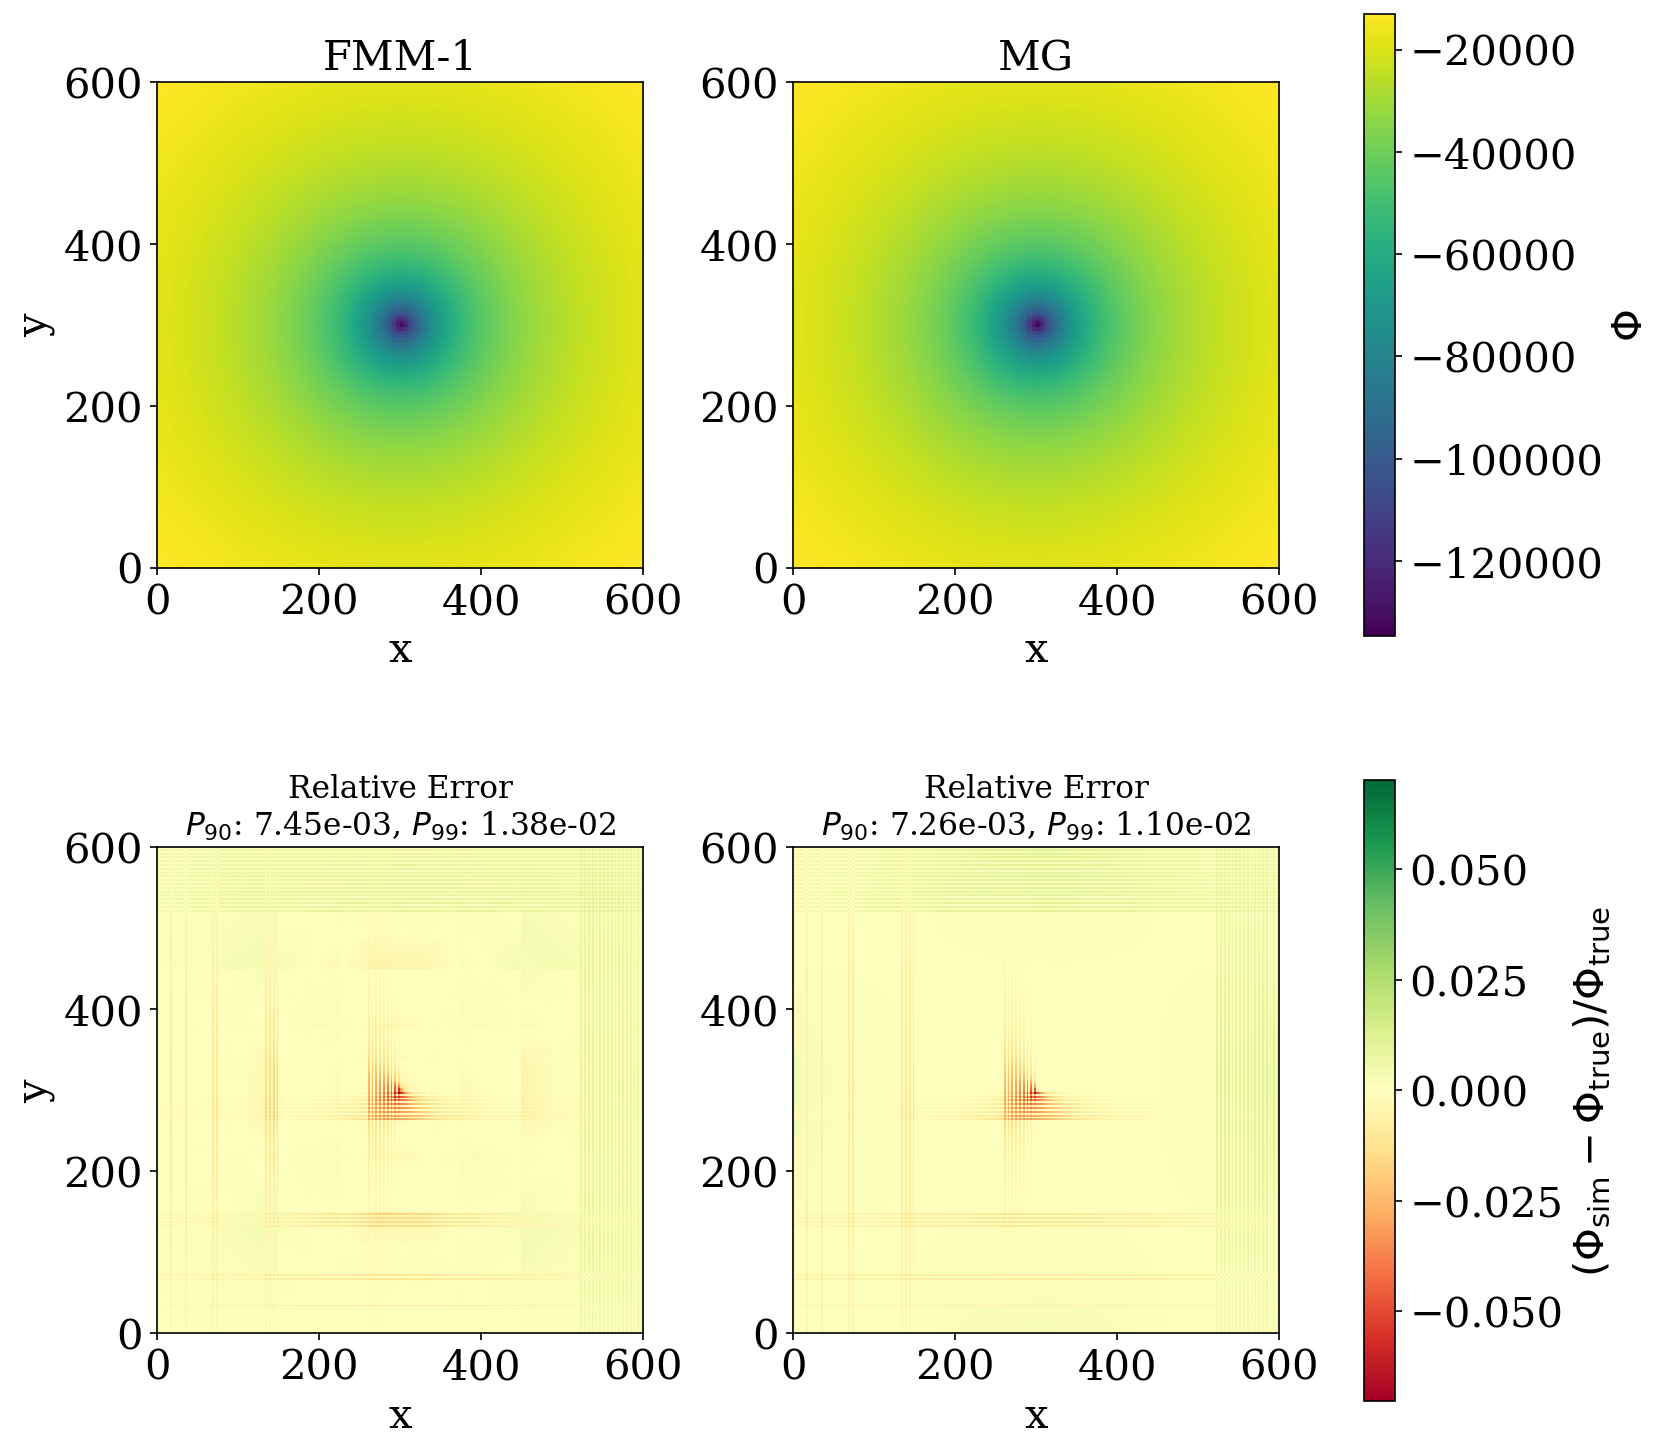

In [29]:
SHIFTED2_FMM_OUTPUT = ROOT / "shift_halo3" / "fmm" / "output_00002"
SHIFTED2_MG_OUTPUT = ROOT / "shift_halo3" / "mg" / "output_00002"
SHIFTED2_DIRECT_REFERENCE = Path("./txt/direct_phi_shifted3_slice_lvl9_zcell128.txt")

for plot_col in ["phi"]:
    plot_shifted_vs_direct(
        plot_col=plot_col,
        fmm_output=SHIFTED2_FMM_OUTPUT,
        mg_output=SHIFTED2_MG_OUTPUT,
        reference_file=SHIFTED2_DIRECT_REFERENCE,
        output_prefix="shifted2_fmm1_mg_vs_direct",
    )
